# Assignment 9 — Image Classification using Pretrained Vision Transformer and CNN

**Objective:** Perform image classification on the CIFAR-10 dataset using:
1. A CNN model trained from scratch.
2. A pretrained Vision Transformer (ViT) model.

Then compare their performance using accuracy, precision, recall, F1-score, confusion matrices, training time, and a final comparison table.

**Dataset:** CIFAR-10 (10 classes, 32×32 RGB images)



In [1]:
# Install required libraries
%pip install -q torch torchvision transformers datasets accelerate scikit-learn matplotlib seaborn pandas pillow

In [2]:
# Imports
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from transformers import (
    ViTImageProcessor,
    ViTForImageClassification,
    TrainingArguments,
    Trainer
)

from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PyTorch version:", torch.__version__)

Device: cuda
PyTorch version: 2.11.0+cu130


## 1. Load the CIFAR-10 Dataset

In [3]:
# CIFAR-10 class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Basic transform for CNN
cnn_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

train_full = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=cnn_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=cnn_transform
)

# Use 45,000 training and 5,000 validation images
train_dataset, val_dataset = random_split(
    train_full,
    [45000, 5000],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

100%|██████████| 170M/170M [00:05<00:00, 29.2MB/s]


Training images: 45000
Validation images: 5000
Test images: 10000


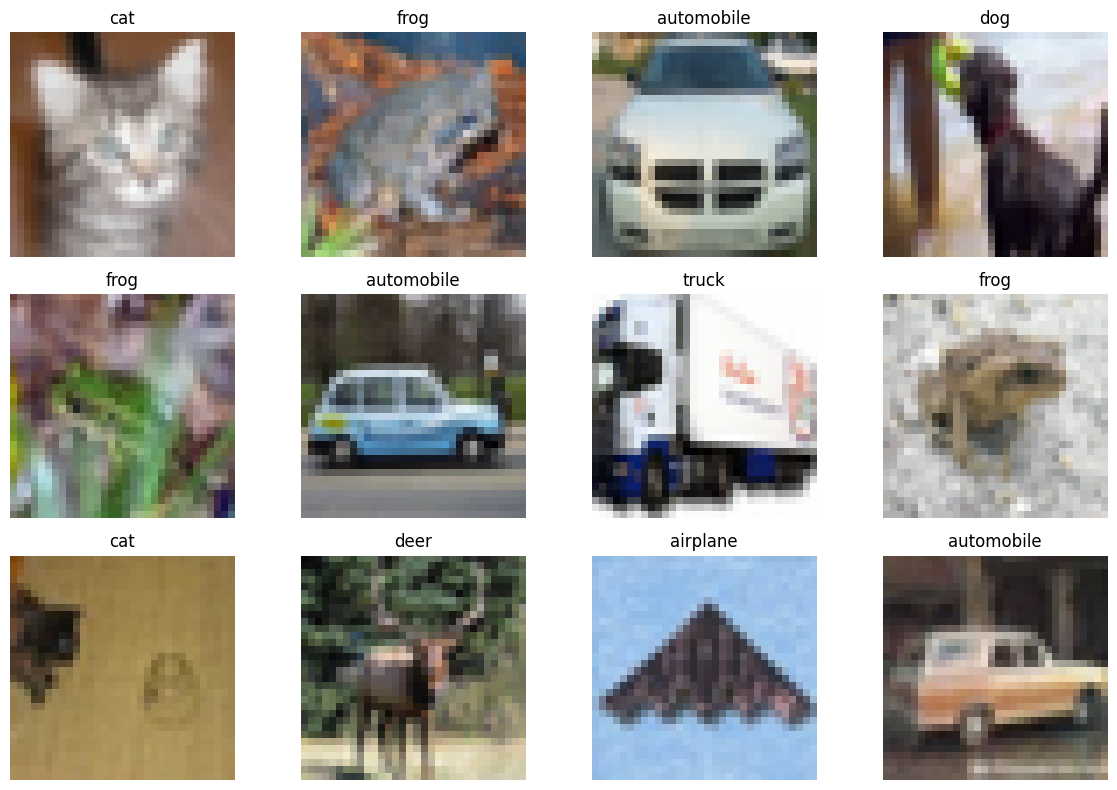

In [4]:
# Display sample images
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(12):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array((0.2470, 0.2435, 0.2616)) + np.array((0.4914, 0.4822, 0.4465))
    img = np.clip(img, 0, 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Build and Train the CNN Model

In [5]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


cnn_model = CNNModel().to(device)
print(cnn_model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [6]:
def train_cnn(model, train_loader, val_loader, epochs=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_state = None
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == targets).sum().item()
            total += targets.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                val_loss_sum += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(1) == targets).sum().item()
                val_total += targets.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    elapsed = time.time() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, elapsed


CNN_EPOCHS = 5
cnn_history, cnn_train_time = train_cnn(
    cnn_model, train_loader, val_loader, epochs=CNN_EPOCHS
)

print(f"\nCNN training time: {cnn_train_time/60:.2f} minutes")

Epoch 1/5 | Train Loss: 1.4022 | Train Acc: 0.4828 | Val Loss: 1.3926 | Val Acc: 0.4934
Epoch 2/5 | Train Loss: 1.0496 | Train Acc: 0.6260 | Val Loss: 1.0666 | Val Acc: 0.6274
Epoch 3/5 | Train Loss: 0.8921 | Train Acc: 0.6860 | Val Loss: 0.9171 | Val Acc: 0.6786
Epoch 4/5 | Train Loss: 0.7932 | Train Acc: 0.7212 | Val Loss: 0.8337 | Val Acc: 0.7000
Epoch 5/5 | Train Loss: 0.7131 | Train Acc: 0.7540 | Val Loss: 0.8672 | Val Acc: 0.6990

CNN training time: 1.53 minutes


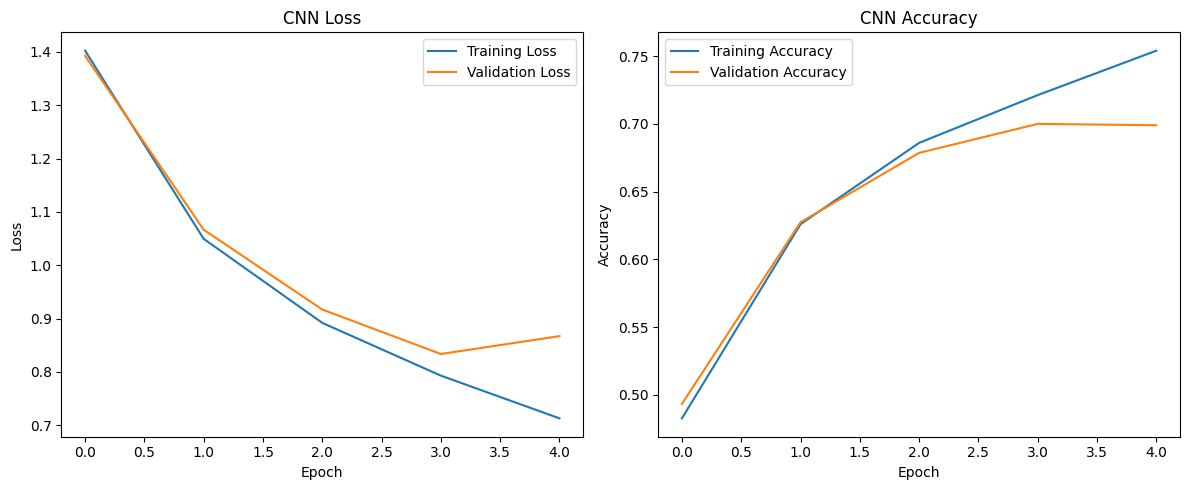

In [7]:
# Plot CNN training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history["train_loss"], label="Training Loss")
plt.plot(cnn_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history["train_acc"], label="Training Accuracy")
plt.plot(cnn_history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
def evaluate_torch_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


cnn_y_true, cnn_y_pred = evaluate_torch_model(cnn_model, test_loader)

cnn_accuracy = accuracy_score(cnn_y_true, cnn_y_pred)
cnn_precision = precision_score(cnn_y_true, cnn_y_pred, average="weighted", zero_division=0)
cnn_recall = recall_score(cnn_y_true, cnn_y_pred, average="weighted", zero_division=0)
cnn_f1 = f1_score(cnn_y_true, cnn_y_pred, average="weighted", zero_division=0)

print("CNN Performance")
print(f"Accuracy : {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall   : {cnn_recall:.4f}")
print(f"F1-score : {cnn_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    cnn_y_true, cnn_y_pred,
    target_names=class_names,
    digits=4
))

CNN Performance
Accuracy : 0.7025
Precision: 0.7354
Recall   : 0.7025
F1-score : 0.7069

Classification Report:
              precision    recall  f1-score   support

    airplane     0.7521    0.7160    0.7336      1000
  automobile     0.7518    0.9270    0.8303      1000
        bird     0.4396    0.7940    0.5659      1000
         cat     0.5787    0.4520    0.5076      1000
        deer     0.7442    0.6140    0.6729      1000
         dog     0.6308    0.6850    0.6568      1000
        frog     0.8447    0.7400    0.7889      1000
       horse     0.7638    0.7600    0.7619      1000
        ship     0.9379    0.6950    0.7984      1000
       truck     0.9106    0.6420    0.7531      1000

    accuracy                         0.7025     10000
   macro avg     0.7354    0.7025    0.7069     10000
weighted avg     0.7354    0.7025    0.7069     10000



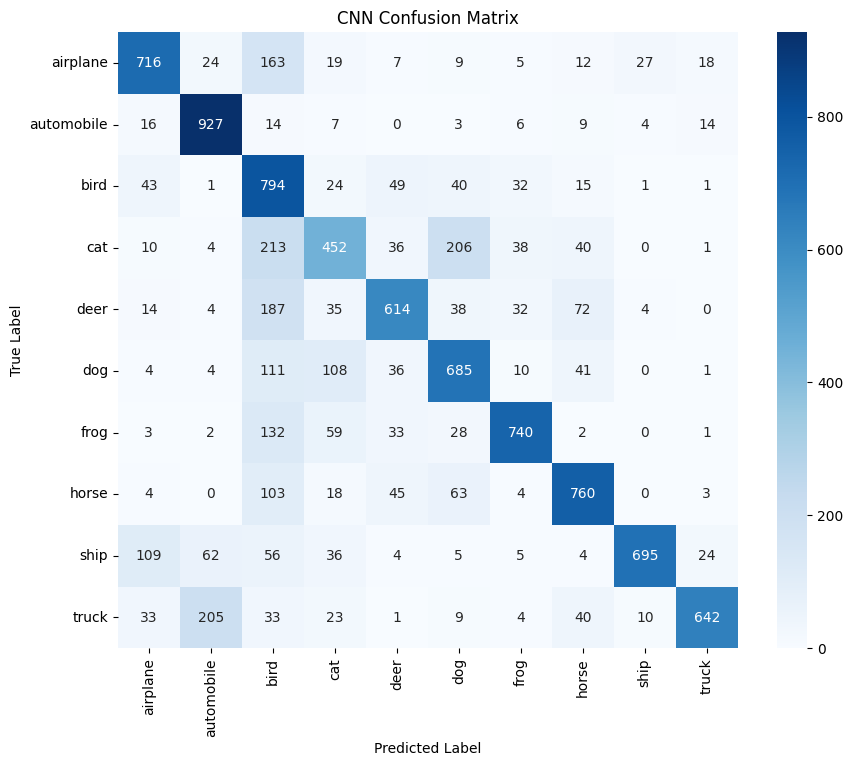

In [9]:
# CNN confusion matrix
cm_cnn = confusion_matrix(cnn_y_true, cnn_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_cnn, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")
plt.show()

## 3. Prepare CIFAR-10 for the Pretrained Vision Transformer

We use **ViT-Base-Patch16-224** pretrained on ImageNet-21k. CIFAR-10 images are resized to 224×224 and normalized using the processor expected by the pretrained model.

In [10]:
# Hugging Face Vision Transformer setup
MODEL_NAME = "google/vit-base-patch16-224-in21k"

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

# Create a separate raw CIFAR-10 dataset for ViT.
# No normalization here; the processor performs the required preprocessing.
vit_train_full = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=None
)

vit_test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=None
)

vit_train_dataset, vit_val_dataset = random_split(
    vit_train_full,
    [45000, 5000],
    generator=torch.Generator().manual_seed(SEED)
)

print("ViT training images:", len(vit_train_dataset))
print("ViT validation images:", len(vit_val_dataset))
print("ViT test images:", len(vit_test_dataset))

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

ViT training images: 45000
ViT validation images: 5000
ViT test images: 10000


In [11]:
# Convert CIFAR-10 samples into the format expected by Hugging Face Trainer
class CIFAR10ViTDataset(torch.utils.data.Dataset):
    def __init__(self, subset, processor):
        self.subset = subset
        self.processor = processor

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]

        # CIFAR-10 returns a PIL image when transform=None
        encoded = self.processor(images=image, return_tensors="pt")

        return {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "labels": label
        }


vit_train = CIFAR10ViTDataset(vit_train_dataset, processor)
vit_val = CIFAR10ViTDataset(vit_val_dataset, processor)
vit_test = CIFAR10ViTDataset(vit_test_dataset, processor)

sample = vit_train[0]
print("Pixel values shape:", sample["pixel_values"].shape)
print("Label:", sample["labels"], class_names[sample["labels"]])

Pixel values shape: torch.Size([3, 224, 224])
Label: 6 frog


In [12]:
# Load pretrained ViT and replace the classifier for CIFAR-10
id2label = {i: name for i, name in enumerate(class_names)}
label2id = {name: i for i, name in enumerate(class_names)}

vit_model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=10,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

vit_model = vit_model.to(device)

print("ViT model loaded.")
print("Number of parameters:",
      sum(p.numel() for p in vit_model.parameters()))

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViT model loaded.
Number of parameters: 85806346


In [13]:
# Metrics for Hugging Face Trainer
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(
            labels, predictions, average="weighted", zero_division=0
        ),
        "recall": recall_score(
            labels, predictions, average="weighted", zero_division=0
        ),
        "f1": f1_score(
            labels, predictions, average="weighted", zero_division=0
        )
    }


# Training configuration
# For CPU, reduce epochs/batch size if training is too slow.
vit_batch_size = 16 if torch.cuda.is_available() else 4

training_args = TrainingArguments(
    output_dir="./vit_cifar10_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=vit_batch_size,
    per_device_eval_batch_size=vit_batch_size,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    remove_unused_columns=False,
    report_to="none",
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=vit_model,
    args=training_args,
    train_dataset=vit_train,
    eval_dataset=vit_val,
    compute_metrics=compute_metrics
)

print("Trainer is ready.")

Trainer is ready.


In [14]:
# Fine-tune pretrained ViT
print("Starting ViT fine-tuning...")
vit_start = time.time()

train_result = trainer.train()

vit_train_time = time.time() - vit_start

print(f"\nViT training time: {vit_train_time/60:.2f} minutes")

Starting ViT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.295406,0.087928,0.981200,0.981504,0.981200,0.981184
2,0.032078,0.064822,0.983400,0.983458,0.983400,0.983403


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before


ViT training time: 18.61 minutes


In [15]:
# Evaluate ViT on the test set
vit_test_output = trainer.predict(vit_test)

vit_y_true = vit_test_output.label_ids
vit_y_pred = np.argmax(vit_test_output.predictions, axis=1)

vit_accuracy = accuracy_score(vit_y_true, vit_y_pred)
vit_precision = precision_score(vit_y_true, vit_y_pred, average="weighted", zero_division=0)
vit_recall = recall_score(vit_y_true, vit_y_pred, average="weighted", zero_division=0)
vit_f1 = f1_score(vit_y_true, vit_y_pred, average="weighted", zero_division=0)

print("Vision Transformer Performance")
print(f"Accuracy : {vit_accuracy:.4f}")
print(f"Precision: {vit_precision:.4f}")
print(f"Recall   : {vit_recall:.4f}")
print(f"F1-score : {vit_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    vit_y_true, vit_y_pred,
    target_names=class_names,
    digits=4
))

Vision Transformer Performance
Accuracy : 0.9845
Precision: 0.9845
Recall   : 0.9845
F1-score : 0.9845

Classification Report:
              precision    recall  f1-score   support

    airplane     0.9920    0.9860    0.9890      1000
  automobile     0.9811    0.9870    0.9840      1000
        bird     0.9929    0.9840    0.9884      1000
         cat     0.9650    0.9640    0.9645      1000
        deer     0.9860    0.9880    0.9870      1000
         dog     0.9660    0.9670    0.9665      1000
        frog     0.9940    0.9970    0.9955      1000
       horse     0.9950    0.9950    0.9950      1000
        ship     0.9881    0.9960    0.9920      1000
       truck     0.9849    0.9810    0.9830      1000

    accuracy                         0.9845     10000
   macro avg     0.9845    0.9845    0.9845     10000
weighted avg     0.9845    0.9845    0.9845     10000



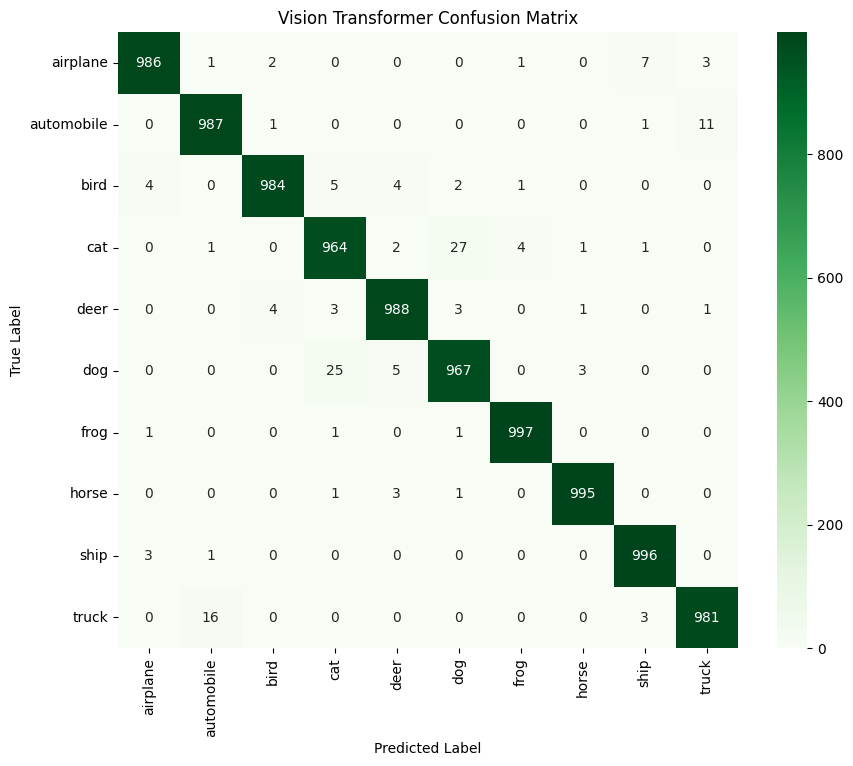

In [16]:
# ViT confusion matrix
cm_vit = confusion_matrix(vit_y_true, vit_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_vit, annot=True, fmt="d", cmap="Greens",
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Vision Transformer Confusion Matrix")
plt.show()

## 4. Compare CNN and Vision Transformer Performance

In [17]:
comparison = pd.DataFrame({
    "Model": ["CNN", "Pretrained ViT"],
    "Accuracy": [cnn_accuracy, vit_accuracy],
    "Precision": [cnn_precision, vit_precision],
    "Recall": [cnn_recall, vit_recall],
    "F1-Score": [cnn_f1, vit_f1],
    "Training Time (min)": [
        cnn_train_time / 60,
        vit_train_time / 60
    ]
})

comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "Training Time (min)": "{:.2f}"
})

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (min)
0,CNN,0.7025,0.7354,0.7025,0.7069,1.53
1,Pretrained ViT,0.9845,0.9845,0.9845,0.9845,18.61


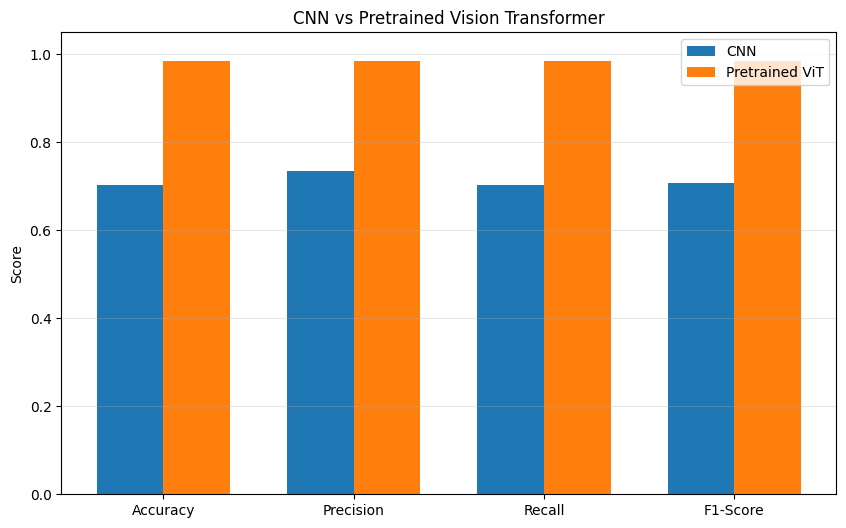

In [18]:
# Visual comparison
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, comparison.loc[0, metrics].values.astype(float),
        width, label="CNN")
plt.bar(x + width/2, comparison.loc[1, metrics].values.astype(float),
        width, label="Pretrained ViT")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("CNN vs Pretrained Vision Transformer")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

In [19]:
# Determine the better model
best_model = comparison.loc[comparison["Accuracy"].idxmax(), "Model"]
best_accuracy = comparison["Accuracy"].max()

print("Best model based on test accuracy:", best_model)
print(f"Best test accuracy: {best_accuracy:.4f}")

print("\nAccuracy improvement of ViT over CNN:",
      f"{(vit_accuracy - cnn_accuracy) * 100:.2f} percentage points")

Best model based on test accuracy: Pretrained ViT
Best test accuracy: 0.9845

Accuracy improvement of ViT over CNN: 28.20 percentage points


## 5. Test Predictions — Visual Comparison

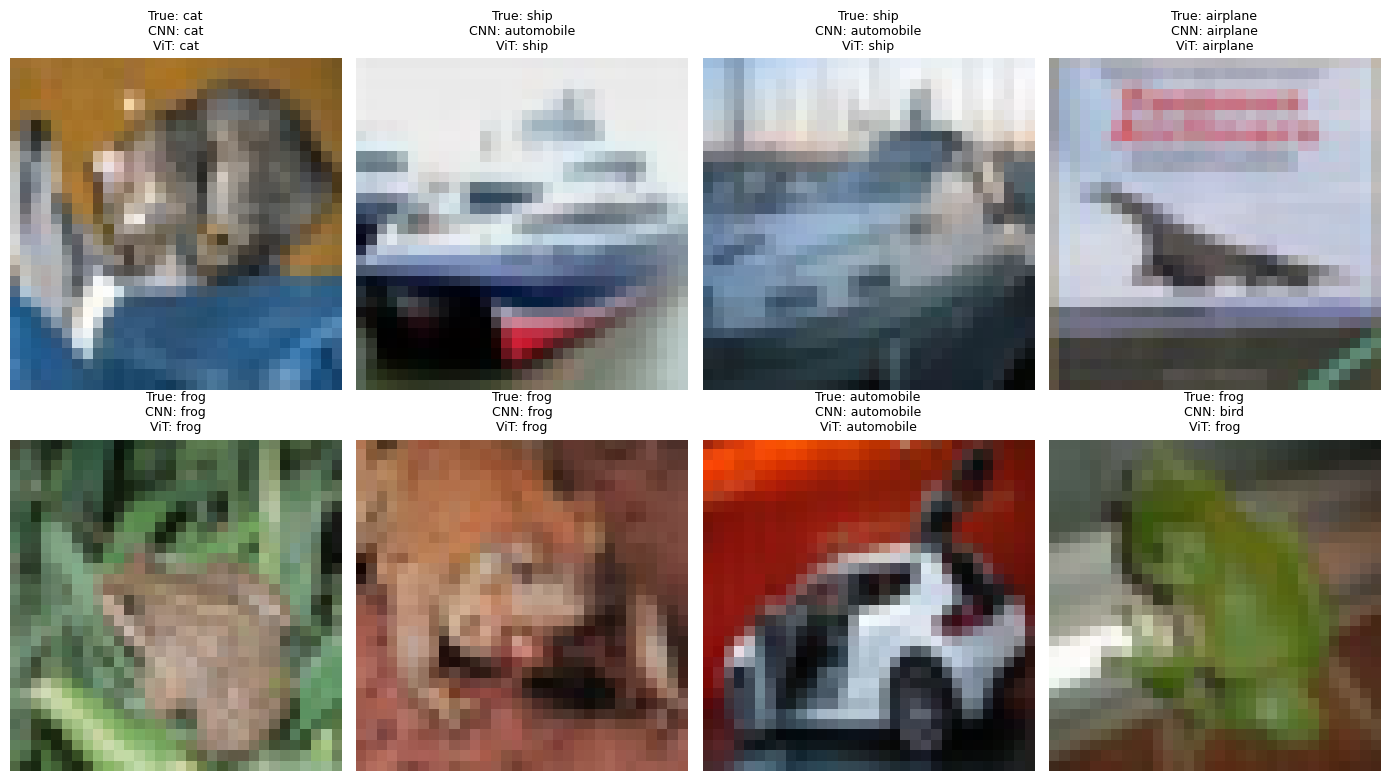

In [20]:
# Display selected test images with CNN and ViT predictions

# Get raw images directly from CIFAR-10
raw_test = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=None
)

indices = [0, 1, 2, 3, 4, 5, 6, 7]

plt.figure(figsize=(14, 8))

for plot_idx, idx in enumerate(indices):
    image, true_label = raw_test[idx]

    # CNN prediction
    cnn_input = cnn_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        cnn_output = cnn_model(cnn_input)
        cnn_pred = cnn_output.argmax(1).item()

    # ViT prediction
    vit_input = processor(images=image, return_tensors="pt")
    vit_input = {k: v.to(device) for k, v in vit_input.items()}

    with torch.no_grad():
        vit_output = vit_model(**vit_input)
        vit_pred = vit_output.logits.argmax(1).item()

    plt.subplot(2, 4, plot_idx + 1)
    plt.imshow(image)
    plt.title(
        f"True: {class_names[true_label]}\n"
        f"CNN: {class_names[cnn_pred]}\n"
        f"ViT: {class_names[vit_pred]}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Final Conclusion

### Conclusion

In this experiment, image classification was performed on the CIFAR-10 dataset using a conventional CNN and a pretrained Vision Transformer (ViT).

The CNN learns spatial features through convolution and pooling operations. It is computationally efficient and is particularly suitable for image datasets where local visual patterns are important.

The pretrained ViT uses self-attention to model relationships between image patches. Since it starts from weights learned on a large image dataset, fine-tuning can provide strong performance on the target classification task.

The final comparison table above shows the actual performance obtained during execution. The model with the higher test accuracy and F1-score can be considered the better-performing model for this experiment.

**Key observations:**
- CNNs are relatively lightweight and faster to train from scratch.
- Pretrained ViTs can leverage transfer learning from large-scale image datasets.
- ViTs generally require more computational resources than a small CNN.
- The final choice depends on accuracy requirements, available hardware, training time, and deployment constraints.

**Result:** The experiment successfully demonstrates image classification using both CNN and a pretrained Vision Transformer and provides a quantitative comparison of their performance.